In [1]:
#!/usr/bin/env python3
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
import nltk
from tqdm import tqdm
nltk.download('punkt')


c:\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\JL211\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
import torch

JSON_DIR = r'C:\Users\JL211\Desktop\tra301_final\data\raw'
json_files = [
    os.path.join(JSON_DIR, fn)
    for fn in os.listdir(JSON_DIR)
    if fn.startswith('ARXIV_') and fn.endswith('.json')
]

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)


cosine_scores = []

for path in tqdm(json_files, desc="Processing JSON files"):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    abstract = data.get('main', {}).get('abstract')
    if not isinstance(abstract, str) or not abstract.strip():
        continue

    refs = [r.get('abstract') for r in data.get('references', [])]
    ref_sents = []
    for r in refs:
        if isinstance(r, str) and r.strip():
            ref_sents += nltk.sent_tokenize(r)
    if not ref_sents:
        continue

    sents = nltk.sent_tokenize(abstract)
    ref_sents = []
    for r in refs:
        ref_sents += nltk.sent_tokenize(r)
    
    if not sents or not ref_sents:
        continue
    
    sent_embeds = model.encode(sents, convert_to_tensor=True)
    ref_embeds = model.encode(ref_sents, convert_to_tensor=True)
    
    sims = util.pytorch_cos_sim(sent_embeds, ref_embeds)
    max_sims = sims.max(dim=1).values.cpu().numpy()
    cosine_scores.extend(max_sims.tolist())

Processing JSON files: 100%|██████████| 7038/7038 [11:20<00:00, 10.33it/s]


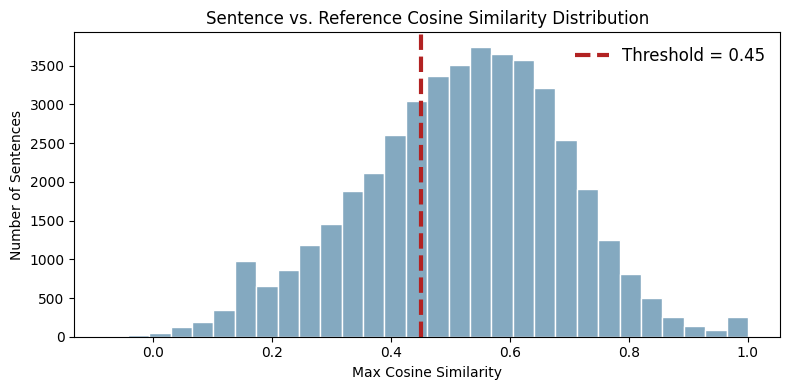

<Figure size 640x480 with 0 Axes>

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(cosine_scores,
         bins=30,
         edgecolor='white',
         color='#84A9C0')  

plt.axvline(0.45,
            color='firebrick',
            linestyle='--',
            linewidth=3,
            label='Threshold = 0.45')

plt.title('Sentence vs. Reference Cosine Similarity Distribution')
plt.xlabel('Max Cosine Similarity')
plt.ylabel('Number of Sentences')
plt.legend(frameon=False, fontsize='large')
plt.tight_layout()
plt.show()